<div style="
    background-color: #7BAFD4;
    border-radius: 18px;
    padding: 22px 26px;
    display: flex;
    align-items: center;
    gap: 24px;
    margin-bottom: 18px;
">
    <img src="592_avatar_lr.png" alt="GEOG 592"
        style="width:110px;height:110px;border-radius:22px;">
    <div>
        <div style="
            font-family: Impact, 'Arial Black', Arial, sans-serif;
            font-size: 42px;
            font-weight: 900;
            letter-spacing: 2px;
            line-height: 1;
            color: white;
        ">GEOG 592</div>
        <div style="
            font-family: Arial, Helvetica, sans-serif;
            font-size: 22px;
            font-weight: 700;
            color: #13294B;
            margin-top: 8px;
        ">GIS Programming</div>
        <div style="
            font-family: Arial, Helvetica, sans-serif;
            font-size: 16px;
            color: #13294B;
            margin-top: 6px;
        ">Homework 8: National Park Visitation vs. Accessibility
        

Assignment description: The project will involve 3 major steps. Each step must answer a different question that builds on each other, involve 2 different layers of spatial data, use a different geoprocessing method, and must include one spatial join and one tabular/attribute join.

Question 1: Where does the national road network occur within National Park boundaries?
- Layers: National Park Boundaries, national roads
- Method: clipping

Question 2: What percent of each National Park is within 100 feet of a road?
- Layers: Output of question 1, nation park polygons
- Method: buffer around the roads, overlay with parks

Question 3: Which parks have the highest overall road access (length and percent accessibility)?
- Layers: National Park Boundaries, output of question 2
- Method: spatial join/aggregation

Final Question/Graph: Are more heavily visited parks more accessible by road?
- Attribute join with NPS visitation data
- Percent of park within 1 mile of roads vs. annual visitors

This jupyter notebook will explain and show all steps that I took to answer these questions!

In [2]:
#Load in the necessary packages for this project
%pip install pyogrio

import pyogrio
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


Since the road and park files needed for this assignment are very large, loading the entire files into geopandas would likely take a very long time to load. Therefore, I will only load small parts of the file in at a time to understand what data I have to work with. I had to use AI to troubleshoot this issue, and it recommended the pyogrio to filter data through geopandas.  

In [3]:
parks_test = gpd.read_file("large_data/national_park_boundaries.geojson", rows=5)

roads_test = gpd.read_file("large_data/us_roads.geojson", rows=5)

print(parks_test.crs)
print(parks_test.columns)

print(roads_test.crs)
print(roads_test.columns)

EPSG:4269
Index(['OBJECTID', 'UNIT_CODE', 'GIS_Notes', 'UNIT_NAME', 'DATE_EDIT', 'STATE',
       'REGION', 'GNIS_ID', 'UNIT_TYPE', 'CREATED_BY', 'METADATA', 'PARKNAME',
       'CreationDa', 'Creator', 'EditDate', 'Editor', 'GlobalID', 'Shape_Leng',
       'Shape_Area', 'geometry'],
      dtype='str')
EPSG:4326
Index(['ID', 'DIR', 'LENGTH', 'LINKID', 'COUNTRY', 'JURISCODE', 'JURISNAME',
       'ROADNUM', 'ROADNAME', 'ADMIN', 'SURFACE', 'LANES', 'SPEEDLIM', 'CLASS',
       'NHS', 'BORDER', 'geometry'],
      dtype='str')


The above code has given me an idea of what columns and types of data are in each datasets. Additionally, it is important to note that the datasets are in different coordinate reference systems (CRS). For now, I am going to focus on the parks dataset and read in slightly more of the file to get an idea of what I'm working with. 

In [4]:
parks_test = gpd.read_file("large_data/national_park_boundaries.geojson",rows=100)

print(parks_test["UNIT_TYPE"].value_counts())

parks = gpd.read_file("large_data/national_park_boundaries.geojson", where="UNIT_TYPE = 'National Park'")

UNIT_TYPE
National Monument               22
National Historic Site          20
National Park                   18
National Historical Park        16
National Recreation Area         6
National Memorial                5
Other Designation                2
National Preserve                2
National Wild & Scenic River     2
National Seashore                2
National River                   1
National Lakeshore               1
National Military Park           1
International Historic Site      1
Parkway                          1
Name: count, dtype: int64


Since there are many different unit types in this dataset, I was able to filter the file for just the boundaries of the national parks, which will significantly trim the size of the dataset and give me a file size that I can work with!

In [5]:
print("Number of National Parks:", len(parks))
print("Park CRS:", parks.crs)
print("Park extent:", parks.total_bounds)

Number of National Parks: 62
Park CRS: EPSG:4269
Park extent: [-170.72755026  -14.28316433  -64.67735791   68.65538816]


Now, I will need to do something similar for the roads dataset, as this file is also too large to work with. I will start with loading in slightly more of the file to get an idea of the data that I'm working with. 

In [ ]:
roads_test = gpd.read_file("large_data/us_roads.geojson",rows=100)

print(roads_test[["COUNTRY", "CLASS", "ADMIN"]].head(20))
print(roads_test["CLASS"].value_counts())


    COUNTRY  CLASS        ADMIN
0         1      2  Territorial
1         1      2  Territorial
2         1      2  Territorial
3         2      5    Municipal
4         2      5    Municipal
5         2      3        State
6         2      3        State
7         2      3        State
8         2      3        State
9         2      3        State
10        2      3        State
11        2      3        State
12        2      3        State
13        2      3        State
14        2      3        State
15        2      3        State
16        2      3        State
17        2      3        State
18        2      3    Municipal
19        1      2  Territorial
CLASS
3    47
2    40
4     6
6     4
5     3
Name: count, dtype: int64


Now, I will only read in the roads that fall within the park boundries. However, to do this I need to create one polygon layer that contains all parks and make sure that CRS aligns across the parks and roads datasets, then use the parks as a mask for the roads. 

In [49]:
park_area = parks.to_crs(roads_test.crs).geometry.union_all()

roads_near_parks = gpd.read_file("large_data/us_roads.geojson",mask=park_area)

print("Roads loaded:", len(roads_near_parks))
print(roads_near_parks.crs)

KeyboardInterrupt: 

Now that I have a geopandas file of roads that is a size we can work with, I need to perform the clip to answer the first question. To do this, I need to make sure the CRS align first, then perform the clip. 

In [8]:
roads_near_parks = roads_near_parks.to_crs(parks.crs)

park_roads = gpd.clip(roads_near_parks, parks)

print("Road segments within parks:", len(park_roads))

Road segments within parks: 755


This code finds that there are 755 national road segments that are located within National Parks. To fully answer the first question (where  the national road network occurs within National Park boundaries), I must map these road segments and the park boundaries. To add overall context, I will add in a layer containing the US boundaries. 

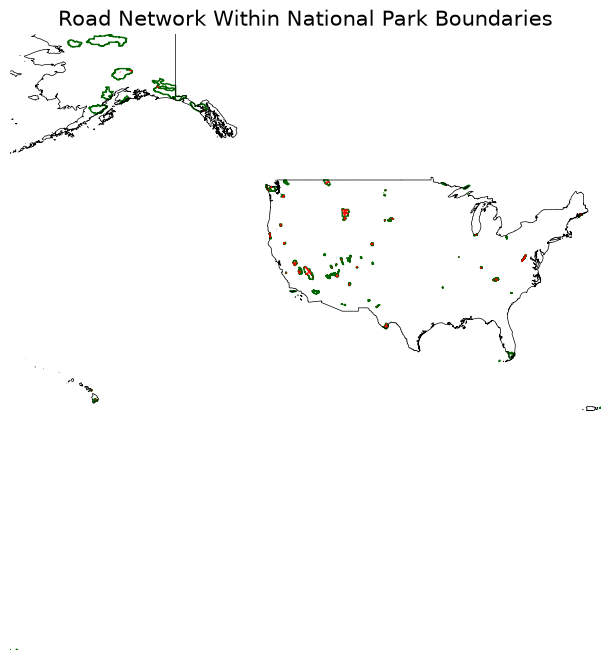

In [9]:
us_boundary = gpd.read_file("data/us_boundaries.geojson")
us_boundary = us_boundary.to_crs(parks.crs)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

us_boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

parks.plot(
    ax=ax,
    facecolor="none",
    edgecolor="darkgreen",
    linewidth=1
)


park_roads.plot(
    ax=ax,
    color="red",
    linewidth=1
)

xmin, ymin, xmax, ymax = parks.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title(
    "Road Network Within National Park Boundaries",
    fontsize=15
)

ax.set_axis_off()

plt.show()

This map shows the roads within national parks and answers the first question of the project: Where does the national road network occur within National Park boundaries?

I struggled a bit with the bounds of the map, as the us_boundary layer includes some island territories that do not contain national parks and distracted from the main map area. Therefore, I had to use AI's help to manually limit the bounds of the us_boundary layer to the bounds of the parks layer. 

Additionally, as the park layer was originally in EPSG 4269,  the road and us boundary layers were set to match this CRS and the overall map is therefore displayed in decimal degrees. 

Now on to question 2!!

Question 2: What percent of each National Park is within 100 feet of a road?

My first step would be to buffer the road layer, but since this question involves distance calculation, we need to ensure that we are in the correct CRS for feet measurement. Since most ESPG relating to feet are on a state level and our data spans the entire US, it would be best to use a US-wide meter CRS and simply convert from feet to meters (100 feet = 30.48 meters) for this calculation. According to Google, EPSG 5070 is the best US-wide CRS for meters. 

In [10]:
park_roads = park_roads.to_crs(epsg=5070)
parks = parks.to_crs(epsg=5070)

print(park_roads.crs)
print(parks.crs)

park_roads["buffer_geometry"] = park_roads.geometry.buffer(30.48)

road_buffers = park_roads[["buffer_geometry"]].copy()
road_buffers = road_buffers.set_geometry("buffer_geometry")
road_buffers = road_buffers.rename_geometry("geometry")
print(road_buffers.crs)

EPSG:5070
EPSG:5070
EPSG:5070


In the above code, I really struggled with the copy method and the geometry column within the road_buffers dataset. Geopandas expects the column containing geometry to be labeled "geometry", therefore I had to rename the buffer_geometry column "geometry" so that geopandas could recognize it. 

Next, I need to perform a spatial join to find the areas within the parks that are accessible by road (intersect with the buffer). Then, to find a percentage, I need to find the original area of each park and the area that intersects with the buffer to calculate the percentage. 

In [11]:
accessible_park = gpd.overlay(parks, road_buffers,how="intersection")

parks["park_area"] = parks.geometry.area
accessible_park["accessible_area"] = accessible_park.geometry.area

accessible_area = (accessible_park.groupby("UNIT_CODE")["accessible_area"].sum())

parks["accessible_area"] = parks["UNIT_CODE"].map(accessible_area).fillna(0)

parks["percent_accessible"] = (parks["accessible_area"] / parks["park_area"] * 100)

print(parks[["UNIT_NAME", "percent_accessible"]])

                           UNIT_NAME  percent_accessible
0            Wind Cave National Park            1.007939
1        Indiana Dunes National Park            2.034629
2      Cuyahoga Valley National Park            0.120046
3               Acadia National Park            0.465752
4             Badlands National Park            0.337862
..                               ...                 ...
57              Katmai National Park            0.000000
58        Kenai Fjords National Park            0.000000
59        Kobuk Valley National Park            0.000000
60          Lake Clark National Park            0.000000
61  Wrangell-St. Elias National Park            0.005677

[62 rows x 2 columns]


In this bit of code, I struggled with the "accessible_area" column in parks, as python kept registering an error when I would try and create this column, claiming that it was a duplicate and the accessible_area column already existed. Therefore, I had to look up the .map method so that I could drop the old accessible_area column and merge the new one into the existing parks data set. Everything else went pretty well!

One important thing to remember is the CRS! As these datasets have all been set to CRS 5070, they are all reporting the area in meters. 

Question 2 is answered! The "percent_accessible" column in the parks dataset now contains the percent of area within 100 feet of a road for every National Park. 

Now onto question 3! Question 3: Which parks have the highest overall road access (length and percent accessibility)?

For this question, I want to look at the length of the road in comparison to the percent_accessibility we've already calculated, which will involve spatially joining the roads with the parks and calculating the road length. As this CRS measures in meters, I will convert these units to miles, so they are in a easily understood unit of measurement. 

In [ ]:
road_park = gpd.sjoin(park_roads, parks[["UNIT_CODE", "UNIT_NAME", "geometry"]], how="left", predicate="within")

road_park["road_length"] = road_park.geometry.length

road_length_by_park = (road_park.groupby(["UNIT_CODE", "UNIT_NAME"])["road_length"].sum().reset_index())

road_length_by_park["road_length_mi"] = (road_length_by_park["road_length"] * 0.000621371)

road_length_by_park = road_length_by_park.merge(parks[["UNIT_CODE", "percent_accessible"]], on="UNIT_CODE", how="left")

print(road_length_by_park.sort_values("road_length_mi", ascending=False).head(10))


   UNIT_CODE                            UNIT_NAME    road_length  \
33      YELL            Yellowstone National Park  411484.831760   
7       DEVA           Death Valley National Park  271036.808017   
34      YOSE               Yosemite National Park  208455.788323   
30      SHEN             Shenandoah National Park  168100.517178   
2       BIBE               Big Bend National Park  112163.866046   
23      MORA          Mount Rainier National Park   91836.066053   
9       GLAC                Glacier National Park   85259.794210   
4       CRLA            Crater Lake National Park   51295.534664   
12      GRSM  Great Smoky Mountains National Park   51143.219316   
1       BADL               Badlands National Park   49374.047877   

    road_length_mi  percent_accessible  
33      255.684741            0.282888  
7       168.414412            0.136132  
34      129.528382            0.424104  
30      104.452786            1.483261  
2        69.695374            0.211674  
23   

In [14]:
print(road_length_by_park.sort_values("percent_accessible", ascending=False).head(10))

   UNIT_CODE                      UNIT_NAME    road_length  road_length_mi  \
18      JEFF     Gateway Arch National Park     847.614731        0.526683   
17      INDU    Indiana Dunes National Park   17319.227406       10.761666   
30      SHEN       Shenandoah National Park  168100.517178      104.452786   
32      WICA        Wind Cave National Park   11548.034137        7.175614   
22      MEVE       Mesa Verde National Park   33492.546242       20.811297   
20      LAVO  Lassen Volcanic National Park    4860.043085        3.019890   
23      MORA    Mount Rainier National Park   91836.066053       57.064268   
21      MACA     Mammoth Cave National Park   29189.277955       18.137371   
27      REDW          Redwood National Park   46136.106824       28.667639   
16      HOSP      Hot Springs National Park    1426.599951        0.886448   

    percent_accessible  
18            8.672029  
17            2.034629  
30            1.483261  
32            1.007939  
22            0.

This code was mostly straightforward, it just involved merging the desired columns from the parks dataset onto the road_length dataset to be able to compare road_length and accessibility side by side. Therefore, the answer to question 3 (which parks have the highest overall road access) shows Yellowstone with the highest overall road length, yet Shenandoah has the highest percent accessibility, probably due to its overall size. The top 10 parks according to road length are: Yellowstone, Death Valley, Yosemite, Shenandoah, Big Bend, Mount Rainier, Glacier, Crater Lake, Great Smoky Mountains, and Badlands. Interestingly, the top 10 according to accessibility are Gateway Arch, Indiana Dunes, Shenandoah, WinD Cave, Mesa Verde, Lassen Volcanic, Mount Rainier, Mammoth Cave, Redwood, and Hot Springs. As Mount Rainier is the only park within the top ten of both, is the answer to question 3!

Now on to the tabular join! I am interested in examining the correlation between park access (both by length and road accessibility) and the annual visitation rates for certain parks. To join the non-spatial visitation data with the existing spatial road_length_by_park dataset, I need to clean the visitation data first.

In [ ]:
visitation = pd.read_csv("data/Annual Visitation and Record Year by Park (1904 - Last Calendar Year).csv")

print(visitation.iloc[:10])
print(visitation.columns)

cleaned_visitation = visitation[visitation["Year"] == 2025]
print(cleaned_visitation.iloc[:10])



      RegionName          ParkName       ParkType  Year      TRV
0  Alaska Region  Denali NP & PRES  National Park  2025  543,300
1  Alaska Region  Denali NP & PRES  National Park  2024  466,227
2  Alaska Region  Denali NP & PRES  National Park  2023  498,722
3  Alaska Region  Denali NP & PRES  National Park  2022  427,562
4  Alaska Region  Denali NP & PRES  National Park  2021  229,521
5  Alaska Region  Denali NP & PRES  National Park  2020   54,850
6  Alaska Region  Denali NP & PRES  National Park  2019  601,152
7  Alaska Region  Denali NP & PRES  National Park  2018  594,660
8  Alaska Region  Denali NP & PRES  National Park  2017  642,809
9  Alaska Region  Denali NP & PRES  National Park  2016  587,412
Index(['RegionName', 'ParkName', 'ParkType', 'Year', 'TRV'], dtype='str')
                 RegionName                       ParkName       ParkType  \
0             Alaska Region               Denali NP & PRES  National Park   
122           Alaska Region  Gates of the Arctic NP & PRE

In [ ]:
cleaned_visitation["ParkName"] = cleaned_visitation["ParkName"].str.replace("NP & PRES", "National Park", regex=False).str.replace( "NP", "National Park", regex=False)
print(cleaned_visitation.iloc[:10])

cleaned_visitation = cleaned_visitation[["ParkName", "TRV"]]


                               ParkName        TRV
0                  Denali National Park    543,300
122   Gates of the Arctic National Park     14,923
244           Glacier Bay National Park    740,044
366                Katmai National Park     34,479
488          Kenai Fjords National Park    425,369
610          Kobuk Valley National Park      7,786
732            Lake Clark National Park     19,778
854    Wrangell-St. Elias National Park    108,840
976                Arches National Park  1,511,740
1098             Big Bend National Park    568,104


36

I had to look up how to replace string values in a pandas dataset and the most important thing to remember when coding this was the order. I tried to replace "NP" before replacing "NP & PRES" and it kept giving me an error as the "NP" replacement would be triggered for the "NP & PRES" already. This step was important so that the non-spatial visitation dataset could be joined using similar "ParkName" fields with the geographic data. 

In [ ]:
final_data = road_length_by_park.merge(cleaned_visitation[["ParkName", "TRV"]], left_on="UNIT_NAME", right_on="ParkName", how="left")

print(final_data.head())

  UNIT_CODE                  UNIT_NAME    road_length  road_length_mi  \
0      ACAD       Acadia National Park     888.441504        0.552052   
1      BADL     Badlands National Park   49374.047877       30.679602   
2      BIBE     Big Bend National Park  112163.866046       69.695374   
3      CONG     Congaree National Park    3328.271983        2.068092   
4      CRLA  Crater Lake National Park   51295.534664       31.873558   

   percent_accessible                   ParkName        TRV  
0            0.465752       Acadia National Park  4,079,318  
1            0.337862     Badlands National Park  1,139,361  
2            0.211674     Big Bend National Park    568,104  
3            0.222825     Congaree National Park    287,833  
4            0.524074  Crater Lake National Park    632,242  


Now to answer the final question (Are more heavily visited parks more accessible by road?), we need to graph the relationship between accessibility (both length and percent accessible) and the park visitation. 